# Text Classification with SpaCy

>  A common task in NLP is text classification. This is **"classification" in the conventional machine learning** sense, and it is applied to text. Examples include **spam detection, sentiment analysis, and tagging customer queries**.

> In this tutorial, you'll learn text classification with spaCy. The classifier will **detect spam messages**, a common functionality in most email clients. Here is an overview of the data you'll use:

In [86]:
import pandas as pd

# Loading the spam data
# ham is the label for non-spam messages
spam = pd.read_csv('../Dataset/spam.csv')
spam.head(10)

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## Bag of Words¶
Machine learning models don't learn from raw text data. Instead, you need to convert the text to something numeric.

The simplest common representation is a variation of **one-hot encoding**. You represent each document as a **vector of term frequencies** for each term in the vocabulary. The vocabulary is built from all the **tokens (terms)** in the **corpus (the collection of documents).**

As an example, take the sentences **"Tea is life. Tea is love."** and **"Tea is healthy, calming, and delicious."**s as our corpus. The vocabulary then is **{"tea", "is", "life", "love", "healthy", "calming", "and", "delicious"}** (ignoring punctuation).

For each document, count up how many times a term occurs, and place that count in the appropriate element of a vector. The first sentence has "tea" twice and that is the first position in our vocabulary, so we put the number 2 in the first element of the vector. Our sentences as vectors then look like

𝑣1 = [22110000]
𝑣2 = [11001111]
 
This is called the **bag of words representation**. You can see that documents with similar terms will have similar vectors. Vocabularies frequently have tens of thousands of terms, so these vectors can be very large.

Another common representation is **TF-IDF (Term Frequency - Inverse Document Frequency)**. TF-IDF is similar to bag of words except that each term count is scaled by the term's frequency in the corpus. Using TF-IDF can potentially improve your models. You won't need it here. Feel free to look it up though!

## Building a Bag of Words model
Once you have your documents in a bag of words representation, you can use those vectors as input to any machine learning model. spaCy handles the bag of words conversion and building a simple linear model for you with the TextCategorizer class.

The TextCategorizer is a spaCy **pipe**. **Pipes are classes for processing and transforming tokens**.

When you create a spaCy model with nlp = spacy.load('en_core_web_sm'), there are default pipes that perform part of speech tagging, entity recognition, and other transformations. 

When you run text through a model doc = nlp("Some text here"), the output of the pipes are attached to the tokens in the doc object. The lemmas for token.lemma_ come from one of these pipes.

You can remove or add pipes to models. What we'll do here is create an empty model without any pipes (other than a tokenizer, since all models always have a tokenizer). Then, we'll create a TextCategorizer pipe and add it to the empty model.


> When you call nlp on a text, spaCy first tokenizes the text to produce a Doc object. The Doc is then processed in several different steps – this is also referred to as the **processing pipeline**. 


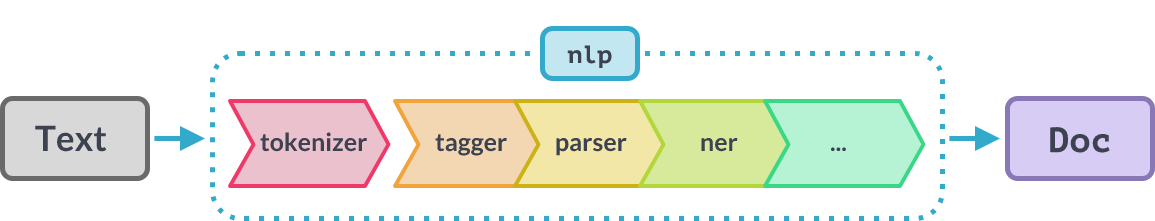


> **NAME	- COMPONENT	- CREATES	-  DESCRIPTION**

    tokenizer	-  Tokenizer	-     Docr	-  Segment text into tokens.


> **PROCESSING PIPELINE**

    tagger	-  Tagger	-  Token.tagr	-  Assign part-of-speech(POS) tags.
    
    parse	-  DependencyParser	-  Token.head, Token.dep, Doc.sents, Doc.noun_chunksr	-  Assign dependency labels.

    ner	-  EntityRecognizer	-  Doc.ents, Token.ent_iob, Token.ent_typer	-  Detect and label named entities.

    lemmatizer	-  Lemmatizer	-  Token.lemma	-  Assign base forms.

    textcat	-  TextCategorizer	-  Doc.cats	-  Assign document labels.

    custom	-  custom components	-  Doc._.xxx, Token._.xxx, Span._.xxx	-  Assign custom attributes, methods or properties.
    
    
 #### When you call **nlp** on a text, spaCy will tokenize it and then call each component on the Doc, in order. It then returns the processed Doc that you can work with.
 
 > doc = nlp("This is a text")

In [87]:
import spacy

# Create an empty model
nlp = spacy.blank("en")

# Create the TextCategorizer with "exclusive classes" and "bow" architecture
# create_pipe method is now mostly used internally To create a component and add it to the pipeline,This is used to create NEW user defined pipeline
#  textcat Assign document labels.
# Here textcat is  text classifier
textcat = nlp.create_pipe(
              "textcat",  # Defining textcat related pipe, similar way we can create any type pipe like lemmatizer, parse etc pipeline = ["tok2vec", "tagger", "parser", "ner"]
              config={
                "exclusive_classes": True,
                "architecture": "bow"})

# Add the TextCategorizer to the empty model WHICH WE defined
nlp.add_pipe(textcat)

In [88]:
textcat


In [89]:
print(nlp.pipe_names)
# In original nlp it gives all pipe list like  # ['tagger', 'parser', 'ner', 'print_info']

['textcat']


> Since the classes are either ham or spam, we set **"exclusive_classes"** to **True**. We've also configured it with the **bag of words ("bow") architecture**. spaCy provides a convolutional neural network architecture as well, but it's more complex than you need for now.


> Next we'll add the labels to the model. Here "ham" are for the real messages, "spam" are spam messages.

In [90]:
# Add labels to text classifier
textcat.add_label("ham")
textcat.add_label("spam")

print(textcat)

## Training a Text Categorizer Model

Next, you'll convert the labels in the data to the form TextCategorizer requires. For each document, you'll create a dictionary of boolean values for each class.


For example, if a text is "ham", we need a dictionary {'ham': True, 'spam': False}. The model is looking for these labels inside another dictionary with the key 'cats'.

In [91]:
train_texts = spam['text'].values

# Here it converts ham or spam value as dictionary of key as cats and values as dictionary of ham and spam with yes or no
train_labels = [{'cats': {'ham': label == 'ham',
                          'spam': label == 'spam'}} 
                for label in spam['label']]

# if spam['label'] = ham -->    {'cats': {'ham': True, 'spam': False}}
#or
#if spam['label'] = spam -->    {'cats': {'ham': False, 'spam': True}}

print(train_texts)
print(train_labels)

['Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
 'Ok lar... Joking wif u oni...'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's"
 ... 'Pity, * was in mood for that. So...any other suggestions?'
 "The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free"
 'Rofl. Its true to its name']
[{'cats': {'ham': True, 'spam': False}}, {'cats': {'ham': True, 'spam': False}}, {'cats': {'ham': False, 'spam': True}}, {'cats': {'ham': True, 'spam': False}}, {'cats': {'ham': True, 'spam': False}}, {'cats': {'ham': False, 'spam': True}}, {'cats': {'ham': True, 'spam': False}}, {'cats': {'ham': True, 'spam': False}}, {'cats': {'ham': False, 'spam': True}}, {'cats': {'ham': False, 'spam': True}}, {'cats': {'ham': True, 'spam': False}}, {'cats': {'ham': True, 'spa

> Then we combine the texts and labels into a single list.

In [93]:
train_data = list(zip(train_texts, train_labels))
train_data[:3]

[('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...',
  {'cats': {'ham': True, 'spam': False}}),
 ('Ok lar... Joking wif u oni...', {'cats': {'ham': True, 'spam': False}}),
 ("Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's",
  {'cats': {'ham': False, 'spam': True}})]

> Now you are ready to train the model. First, create an **optimizer** using **nlp.begin_training()**. spaCy uses this optimizer to update the model. In general it's more efficient to train models in small batches. spaCy provides the minibatch function that returns a generator yielding minibatches for training. Finally, the minibatches are split into texts and labels, then used with nlp.update to update the model's parameters.

In [94]:
from spacy.util import minibatch

spacy.util.fix_random_seed(1)

## Here we are training model by using optimxer to update the model
optimizer = nlp.begin_training()

# Create the batch generator with batch size = 8
batches = minibatch(train_data, size=8)
# Iterate through minibatches
for batch in batches:
    # Each batch is a list of (text, label) but we need to
    # send separate lists for texts and labels to update().
    # This is a quick way to split a list of tuples into lists
    texts, labels = zip(*batch)
    nlp.update(texts, labels, sgd=optimizer)

> This is just one training loop (or epoch) through the data. The model will typically need multiple epochs. Use another loop for more epochs, and optionally re-shuffle the training data at the begining of each loop.

### TextCategorizer.update METHOD
Learn from a batch  and update the component’s model. Delegates to predict and get_loss.

    > sgd  -  An optimizer. Will be created via create_optimizer if not set.

    > losses  - Optional record of the loss during training. Updated using the component name as the key


In [95]:
import random

random.seed(1)
spacy.util.fix_random_seed(1)
optimizer = nlp.begin_training()
# optimizer = nlp.initialize()

losses = {}
for epoch in range(10):
    random.shuffle(train_data)
    # Create the batch generator with batch size = 8
    batches = minibatch(train_data, size=8)
    # Iterate through minibatches
    for batch in batches:
        # Each batch is a list of (text, label) but we need to
        # send separate lists for texts and labels to update().
        # This is a quick way to split a list of tuples into lists
        texts, labels = zip(*batch)
        nlp.update(texts, labels, sgd=optimizer, losses=losses)
        # losses = textcat.update(examples, sgd=optimizer)
    print(losses)

{'textcat': 0.4273221677458423}
{'textcat': 0.6341245385715624}
{'textcat': 0.7633163207539528}
{'textcat': 0.8460238767463153}
{'textcat': 0.9026025289508448}
{'textcat': 0.9385453198385202}
{'textcat': 0.9656774565584434}
{'textcat': 0.9855865327383931}
{'textcat': 0.9993013808462957}
{'textcat': 1.0095627469714605}


## Making Predictions

> Now that you have a trained model, you can make predictions with the **predict()** method. The input text needs to be tokenized with nlp.tokenizer. Then you pass the tokens to the predict method which returns scores. The scores are the probability the input text belongs to the classes.

In [118]:

# New message, we need to predict, here 2 lines are there, It reats both sepearetly and finds it
texts = ["Are you ready for the tea party????? It's gonna be wild",
         "WINNER!! As a valued network customer you have..."]
 #       "URGENT Reply to this message for GUARANTEED FREE TEA" ]
#texts = ["WINNER!! As a valued network customer you have..." ]

print(texts)

# Tokenize the dtext- Segment text into tokens.
docs = [nlp.tokenizer(text) for text in texts]
print(docs)

#Step 1. 
# Done earlier , for blank nlp model textcat pipe added
#nlp.add_pipe(textcat)

## Another way combines 1st and 2nd step
# textcat = nlp.add_pipe("textcat")

#Step 2
# Use textcat to get the scores for each doc, 
#Here textcat is userdefined Pipe used
textcat = nlp.get_pipe('textcat')

# Predict will be in scores
scores, _ = textcat.predict(docs)
# scores = textcat.predict([doc1, doc2])

print(scores)

["Are you ready for the tea party????? It's gonna be wild", 'WINNER!! As a valued network customer you have...']
[Are you ready for the tea party????? It's gonna be wild, WINNER!! As a valued network customer you have...]
[[9.999181e-01 8.191081e-05]
 [4.941324e-01 5.058676e-01]]


> Here 1st list is Ham and Spam probability score of 1st message, in this 1st value( 9.999181e-01) > 2nd value ( 8.191081e-05) . So its HAM message

> Here 2nd list is Ham and Spam probability score of 2nd message, in this 1st value( 4.941324e-01) < 2nd value ( 5.058676e-01) . So its SPAM message


In [119]:
print (docs)
textcat.predict(docs)

[Are you ready for the tea party????? It's gonna be wild, WINNER!! As a valued network customer you have...]


(array([[9.999181e-01, 8.191081e-05],
        [4.941324e-01, 5.058676e-01]], dtype=float32),
 [array([], dtype=float32), array([], dtype=float32)])

> The scores are used to predict a single class or label by choosing the label with the highest probability. You get the index of the highest probability with scores.argmax, then use the index to get the label string from textcat.labels.

In [120]:
# From the scores, find the label with the highest score/probability
# Argmax is most commonly used in machine learning for finding the class with the 
    # largest predicted probability.
# Returns the indices of the maximum values along an axis. Input array. 

predicted_labels = scores.argmax(axis=1)
print(predicted_labels)
#print(textcat.labels)
print([textcat.labels[label] for label in predicted_labels])

[0 1]
['ham', 'spam']


> Evaluating the model is straightforward once you have the predictions. To measure the accuracy, calculate how many correct predictions are made on some test data, divided by the total number of predictions.

### Simple example of Textcat predict


In [121]:
TRAIN_DATA = [
    ("beef", {"cats": {"POSITIVE": 1.0, "NEGATIVE": 0.0}}),
    ("apple", {"cats": {"POSITIVE": 0, "NEGATIVE": 1}})
]

# I'm training a pipe to classify text. It trains and has a low loss rate.

In [126]:

import spacy
nlp1 = spacy.blank("en")
# Newly created pytt_textcat pipe
textcat1 = nlp1.create_pipe("textcat", config={"exclusive_classes": True})

# Added 2 label to this
for label in ("POSITIVE", "NEGATIVE"):
    textcat1.add_label(label)
  
# Add the TextCategorizer to the empty model WHICH WE defined
nlp1.add_pipe(textcat1)

textcat1

In [127]:
# Here it creates epoch of 10 set with random shuffle the data
import random

random.seed(1)
spacy.util.fix_random_seed(1)
optimizer = nlp1.begin_training()
# optimizer = nlp.initialize()

losses = {}
for i in range(10):
    random.shuffle(TRAIN_DATA)
    # Create the batch generator with batch size = 8

    
    for batch in minibatch(TRAIN_DATA, size=8):
        # textcat    -  TextCategorizer    -  Doc.cats    -  Assign document labels.
        texts, cats = zip(*batch)
        nlp1.update(texts, cats, sgd=optimizer, losses=losses)
    print(i, losses)
    


0 {'textcat': 0.125}
1 {'textcat': 0.2498118057847023}
2 {'textcat': 0.3710070922970772}
3 {'textcat': 0.4872167333960533}
4 {'textcat': 0.5954774394631386}
5 {'textcat': 0.691337987780571}
6 {'textcat': 0.7733832225203514}
7 {'textcat': 0.8424941673874855}
8 {'textcat': 0.8995641469955444}
9 {'textcat': 0.9450949989259243}


In [129]:
# Now, how do I predict whether a new string of text is "POSITIVE" or "NEGATIVE"?

doc = nlp1(u'Pork')
# Here  textcat    -  TextCategorizer    -  Doc.cats    -  Assign document labels.

print(doc.cats)

{'POSITIVE': 0.5565518140792847, 'NEGATIVE': 0.44344815611839294}


In [132]:
doc = nlp1(u'apple cider')
# Here  textcat    -  TextCategorizer    -  Doc.cats    -  Assign document labels.

print(doc.cats)

{'POSITIVE': 0.3783995807170868, 'NEGATIVE': 0.6216003894805908}


## Word Embeddings(Word  Vector)

You know at this point that machine learning on text requires that you first represent the **text numerically**. 
So far, you've done this with **bag of words** representations. But you can usually do better with **word embeddings**.

****Word embeddings (also called word vectors)**** represent each word numerically in such a way that **.the vector corresponds to how that word is used or what it means**. Vector encodings are learned by considering the context in which the words appear. 

Words that appear in **.similar contexts**. will have **.similar vectors**.. For example, vectors for "leopard", "lion", and "tiger" will be close together, while they'll be far away from "planet" and "castle".

Even cooler, relations between words can be examined with mathematical operations. Subtracting the vectors for "man" and "woman" will return another vector. If you add that to the vector for "king" the result is close to the vector for "queen."

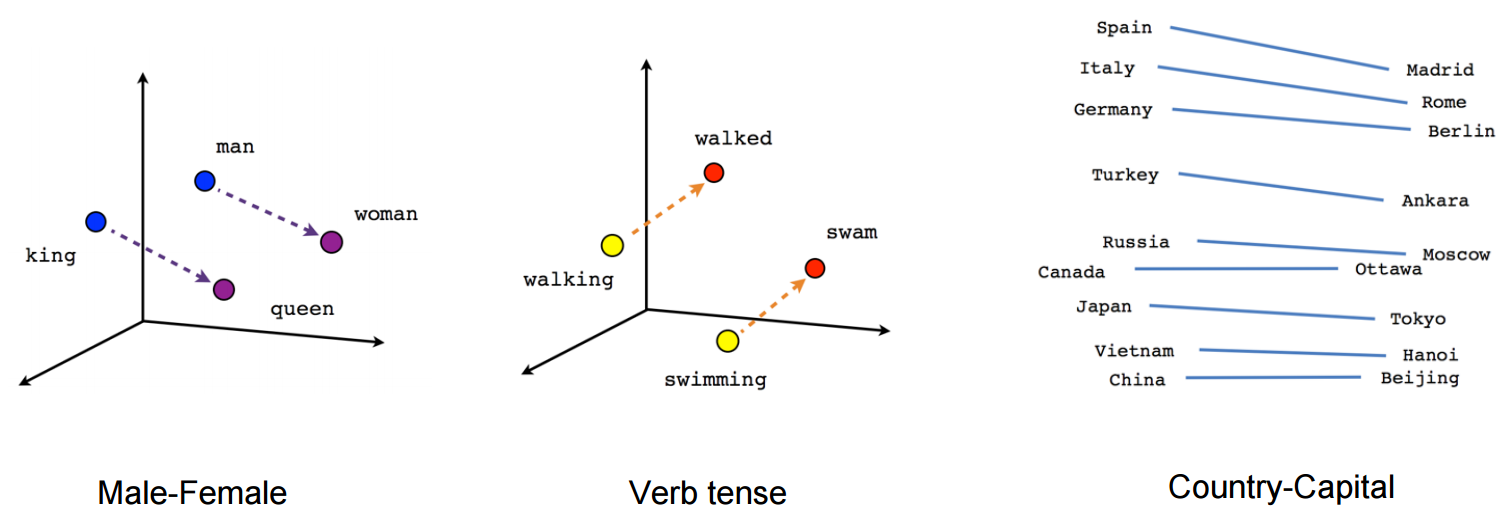Word vector examples

**.Word vector examples**.

These vectors can be used as **.features for machine learning models**.. Word vectors will typically improve the performance of your models **.above bag of words encoding**.. spaCy provides embeddings learned from a model called **.Word2Vec**.. You can access them by loading a large language model like en_core_web_lg. Then they will be available on tokens from the .vector attribute.

In [133]:
import numpy as np
import spacy

# Need to load the Medium model to get the vectors
nlp = spacy.load('en_core_web_md')

In [134]:
# Disabling other pipes because we don't need them and it'll speed up this part a bit

# Here doc in for loop provides each token and token.vector converts each word/token to vector
text = "These vectors can be used as features for machine learning models."

for token in  nlp(text):
    print(token)

These
vectors
can
be
used
as
features
for
machine
learning
models
.


In [135]:
with nlp.disable_pipes():
    vectors = np.array([token.vector for token in  nlp(text)])
print(vectors)

[[-0.1965    -0.13995   -0.52495   ... -0.097467   0.34578   -0.14233  ]
 [ 0.018837  -0.21752   -0.18054   ...  0.16943   -0.35287    0.91983  ]
 [-0.23857    0.35457   -0.30219   ... -0.35283    0.41888    0.13168  ]
 ...
 [ 0.047511   0.1404    -0.11736   ...  0.03169   -0.14208    0.42548  ]
 [ 0.0065037  0.2064     0.0089077 ...  0.033444  -0.030121  -0.12998  ]
 [ 0.012001   0.20751   -0.12578   ...  0.13871   -0.36049   -0.035    ]]


In [136]:
vectors.shape


(12, 300)


> In case of en_core_web_sm  shape is (12, 96) Here 96 dimensions are fixed for en_core_web_sm and 12 are no of token in text 

> In case of en_core_web_md  shape is (12, 300), Here 300 dimensions vector are fixed for en_core_web_md and 12 are no of token in text 

These are 300-dimensional vectors, with one vector for each word. However, we only have document-level labels and our models won't be able to use the word-level embeddings. So, you need a vector representation for the entire document.

There are many ways to combine all the word vectors into a single document vector we can use for model training. A simple and surprisingly effective approach is simply averaging the vectors for each word in the document. Then, you can use these document vectors for modeling.

spaCy calculates the average document vector which you can get with doc.vector. Here is an example loading the spam data and converting it to document vectors.

### Here document vector means vector in row level( row considered as doc i guess)

In [137]:
import pandas as pd

# Loading the spam data
# ham is the label for non-spam messages
spam = pd.read_csv('../Dataset/spam.csv')
spam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5404 entries, 0 to 5403
Data columns (total 2 columns):
label    5404 non-null object
text     5404 non-null object
dtypes: object(2)
memory usage: 84.5+ KB


In [138]:
spam.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [139]:
#in for loop, csv file .text reads csv file in row wise
for text in spam.text:
    print(text)
    print('\n')

Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


Ok lar... Joking wif u oni...


Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's


U dun say so early hor... U c already then say...


Nah I don't think he goes to usf, he lives around here though


FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to send, ?1.50 to rcv


Even my brother is not like to speak with me. They treat me like aids patent.


As per your request 'Melle Melle (Oru Minnaminunginte Nurungu Vettam)' has been set as your callertune for all Callers. Press *9 to copy your friends Callertune


WINNER!! As a valued network customer you have been selected to receivea ?900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.


Had your mobile 11 months o

Update_Now - Xmas Offer! Latest Motorola, SonyEricsson & Nokia & FREE Bluetooth! Double Mins & 1000 Txt on Orange. Call MobileUpd8 on 08000839402 or call2optout/F4Q=


Here is your discount code RP176781. To stop further messages reply stop. www.regalportfolio.co.uk. Customer Services 08717205546


Wat uniform? In where get?


Cool, text me when you're ready


Hello my boytoy ... Geeee I miss you already and I just woke up. I wish you were here in bed with me, cuddling me. I love you ...


I will spoil you in bed as well :)


I'm going for bath will msg you next  &lt;#&gt;  min..


I cant keep talking to people if am not sure i can pay them if they agree to price. So pls tell me what you want to really buy and how much you are willing to pay


Thanks for your Ringtone Order, Reference T91. You will be charged GBP 4 per week. You can unsubscribe at anytime by calling customer services on 09057039994


Can you say what happen


You could have seen me..i did't recognise you Face.:)


Well

Having lunch:)you are not in online?why?


I know that my friend already told that.


Hi Princess! Thank you for the pics. You are very pretty. How are you?


Aiyo... U always c our ex one... I dunno abt mei, she haven reply... First time u reply so fast... Y so lucky not workin huh, got bao by ur sugardad ah...gee.. 


Hi msg me:)i'm in office..


Thanx 4 e brownie it's v nice...


Geeeee ... I love you so much I can barely stand it


GENT! We are trying to contact you. Last weekends draw shows that you won a ?1000 prize GUARANTEED. Call 09064012160. Claim Code K52. Valid 12hrs only. 150ppm 


Fuck babe ... I miss you already, you know ? Can't you let me send you some money towards your net ? I need you ... I want you ... I crave you ...


Ill call u 2mrw at ninish, with my address that icky American freek wont stop callin me 2 bad Jen k eh?


Oooh bed ridden ey? What are YOU thinking of?


So anyways, you can just go to your gym or whatever, my love *smiles* I hope your ok and having

Romantic Paris. 2 nights, 2 flights from ?79 Book now 4 next year. Call 08704439680Ts&Cs apply.


We are at grandmas. Oh dear, u still ill? I felt Shit this morning but i think i am just hungover! Another night then. We leave on sat.


Urgent Ur ?500 guaranteed award is still unclaimed! Call 09066368327 NOW closingdate04/09/02 claimcode M39M51 ?1.50pmmorefrommobile2Bremoved-MobyPOBox734LS27YF


Nothing but we jus tot u would ask cos u ba gua... But we went mt faber yest... Yest jus went out already mah so today not going out... Jus call lor...


Wishing you and your family Merry \X\" mas and HAPPY NEW Year in advance.."


UR awarded a City Break and could WIN a ?200 Summer Shopping spree every WK. Txt STORE to 88039 . SkilGme. TsCs087147403231Winawk!Age16 ?1.50perWKsub


I'm nt goin, got somethin on, unless they meetin 4 dinner lor... Haha, i wonder who will go tis time...


Sorry, I'll call later


I cant pick the phone right now. Pls send a message


Lol I know! They're so dramatic. 

Dear Matthew please call 09063440451 from a landline, your complimentary 4*Lux Tenerife holiday or ?1000 CASH await collection. ppm150 SAE T&Cs Box334 SK38XH.


Then dun wear jeans lor...


Since when, which side, any fever, any vomitin.


K:)k.are you in college?


Urgent! call 09061749602 from Landline. Your complimentary 4* Tenerife Holiday or ?10,000 cash await collection SAE T&Cs BOX 528 HP20 1YF 150ppm 18+


Better. Made up for Friday and stuffed myself like a pig yesterday. Now I feel bleh. But at least its not writhing pain kind of bleh.


No we sell it all so we'll have tons if coins. Then sell our coins to someone thru paypal. Voila! Money back in life pockets:)


Theyre doing it to lots of places. Only hospitals and medical places are safe.


How about getting in touch with folks waiting for company? Just txt back your NAME and AGE to opt in! Enjoy the community (150p/SMS)


And also I've sorta blown him off a couple times recently so id rather not text him out of the blue l

...

Had your contract mobile 11 Mnths? Latest Motorola, Nokia etc. all FREE! Double Mins & Text on Orange tariffs. TEXT YES for callback, no to remove from records


Urgent! call 09066350750 from your landline. Your complimentary 4* Ibiza Holiday or 10,000 cash await collection SAE T&Cs PO BOX 434 SK3 8WP 150 ppm 18+


No plans yet. What are you doing ?


Hi ....My engagement has been fixd on  &lt;#&gt; th of next month. I know its really shocking bt....hmm njan vilikkam....t ws al of a sudn;-(.


Not course. Only maths one day one chapter with in one month we can finish.


Wow didn't think it was that common. I take it all back ur not a freak! Unless u chop it off:-)


For ur chance to win a ?250 wkly shopping spree TXT: SHOP to 80878. T's&C's www.txt-2-shop.com custcare 08715705022, 1x150p/wk


Noooooooo please. Last thing I need is stress. For once in your life be fair.


U have a Secret Admirer who is looking 2 make contact with U-find out who they R*reveal who thinks UR so special-cal

Thanx. Yup we coming back on sun. Finish dinner going back 2 hotel now. Time flies, we're tog 4 exactly a mth today. Hope we'll haf many more mths to come...


We're on the opposite side from where we dropped you off


Yup. Izzit still raining heavily cos i'm in e mrt i can't c outside.


Send me your resume:-)


Gd luck 4 ur exams :-)


Or u ask they all if next sat can a not. If all of them can make it then i'm ok lor.


Sorry that was my uncle. I.ll keep in touch


Saw Guys and Dolls last night with Patrick Swayze it was great


URGENT This is our 2nd attempt to contact U. Your ?900 prize from YESTERDAY is still awaiting collection. To claim CALL NOW 09061702893


Santa calling! Would your little ones like a call from Santa Xmas Eve? Call 09077818151 to book you time. Calls1.50ppm last 3mins 30s T&C www.santacalling.com


Just come home. I don't want u to be miserable


I dont know why she.s not getting your messages


its cool but tyler had to take off so we're gonna buy for him an

Oops I was in the shower when u called. Hey a parking garage collapsed at university hospital. See I'm not crazy. Stuff like that DOES happen.


Aiyo u so poor thing... Then u dun wan 2 eat? U bathe already?


Yar... I tot u knew dis would happen long ago already.


You are gorgeous! keep those pix cumming :) thank you!


A boy was late 2 home. His father: \POWER OF FRNDSHIP\""


JADE ITS PAUL. Y DIDN?T U TXT ME? DO U REMEMBER ME FROM BARMED? I WANT 2 TALK 2 U! TXT ME


Spending new years with my brother and his family. Lets plan to meet next week. Are you ready to be spoiled? :)


So what u doing today?


I said its okay. Sorry


Slept? I thinkThis time ( &lt;#&gt;  pm) is not dangerous


Networking job is there.


goldviking (29/M) is inviting you to be his friend. Reply YES-762 or NO-762 See him: www.SMS.ac/u/goldviking STOP? Send STOP FRND to 62468


Dont let studying stress you out. L8r.


That's y u haf 2 keep me busy...


No rushing. I'm not working. I'm in school so if we rush 

Congrats 2 mobile 3G Videophones R yours. call 09063458130 now! videochat wid ur mates, play java games, Dload polypH music, noline rentl. bx420. ip4. 5we. 150p


?? still got lessons?  ?? in sch?


Y she dun believe leh? I tot i told her it's true already. I thk she muz c us tog then she believe.


Oh did you charge camera


I??e got some salt, you can rub it in my open wounds if you like!


Now i'm going for lunch.


I'm in school now n i'll be in da lab doing some stuff give me a call when ?_ r done.


Oh k. . I will come tomorrow


Aight, text me tonight and we'll see what's up


U 2.


Water logging in desert. Geoenvironmental implications.


Raji..pls do me a favour. Pls convey my Birthday wishes to Nimya. Pls. Today is her birthday.


Company is very good.environment is terrific and food is really nice:)


Very strange.  and  are watching the 2nd one now but i'm in bed. Sweet dreams, miss u 


SMS AUCTION - A BRAND NEW Nokia 7250 is up 4 auction today! Auction is FREE 2 join & t

Do u konw waht is rael FRIENDSHIP Im gving yuo an exmpel: Jsut ese tihs msg.. Evrey splleing of tihs msg is wrnog.. Bt sitll yuo can raed it wihtuot ayn mitsake.. GOODNIGHT &amp; HAVE A NICE SLEEP..SWEET DREAMS..


I cant pick the phone right now. Pls send a message


I don't want you to leave. But i'm barely doing what i can to stay sane. fighting with you constantly isn't helping.


The current leading bid is 151. To pause this auction send OUT. Customer Care: 08718726270


Free entry to the gr8prizes wkly comp 4 a chance to win the latest Nokia 8800, PSP or ?250 cash every wk.TXT GREAT to 80878 http//www.gr8prizes.com 08715705022


Somebody set up a website where you can play hold em using eve online spacebucks


Its sunny in california. The weather's just cool


You have 1 new message. Call 0207-083-6089


I can make it up there, squeezed  &lt;#&gt;  bucks out of my dad


Good day to You too.Pray for me.Remove the teeth as its painful maintaining other stuff.


How are you babes. H

In [140]:
# nlp func (Text to doc and doc to vect conv) applied in each row level
# here with function : with statement in Python is used in exception handling to make the code cleaner and much more readable. It
with nlp.disable_pipes():
    doc_vectors = np.array([nlp(text).vector for text in spam.text])
    
print(doc_vectors)

[[-0.03657657  0.07588542 -0.02465773 ... -0.06323574  0.01894343
   0.22145511]
 [-0.12764603  0.02142075 -0.16055925 ...  0.02559957  0.10382
   0.38030246]
 [-0.00741816  0.02193648  0.02771568 ... -0.07458528  0.09437574
   0.12633726]
 ...
 [-0.05494839  0.19570266 -0.13729948 ... -0.10815047 -0.02305553
   0.18632641]
 [-0.06460267  0.17402254 -0.21391848 ... -0.02812874  0.04536904
   0.21436742]
 [ 0.09184885  0.14416684 -0.2082083  ...  0.03214014 -0.04769757
   0.19402859]]


In [141]:
doc_vectors.shape

(5404, 300)

> In case of en_core_web_sm  shape is (5404, 96) Here 96 dimensions are fixed for en_core_web_sm and 5404 are no of records in csv 5404 are no of records in csv 

>  In case of en_core_web_md  shape is (5404, 300), Here 300 dimensions vector are fixed for en_core_web_md and 5404 are no of token in csv 

## Classification Models
With the document vectors, you can train scikit-learn models, xgboost models, or any other standard approach to modeling.

> Once we convert text to doc and doc to vector, we can apply any ML models

In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(doc_vectors, spam.label,
                                                    test_size=0.1, random_state=1)

Here is an example using **support vector machines (SVMs)**. Scikit-learn provides an SVM classifier LinearSVC. This works similar to other scikit-learn models.

In [143]:
from sklearn.svm import LinearSVC

# Set dual=False to speed up training, and it's not needed
svc = LinearSVC(random_state=1, dual=False, max_iter=10000)
svc.fit(X_train, y_train)
print(f"Accuracy: {svc.score(X_test, y_test) * 100:.3f}%", )

Accuracy: 97.227%


## Document Similarity  - cosine similarity  (This is one of  word embedding)

Documents with **similar content generally have similar vectors**. So you can find similar documents by measuring the similarity between the vectors. A common metric for this is the **cosine similarity** which measures the angle between two vectors,  a  and  b .


cosθ=a⋅b∥a∥∥b∥
 

This is the dot product of  a  and  b , divided by the magnitudes of each vector. The cosine similarity can vary between -1 and 1, corresponding complete opposite to perfect similarity, respectively. To calculate it, you can use the metric from scikit-learn or write your own function.

> Among different distance metrics, cosine similarity is more intuitive and most used in word2vec. It is normalized dot product of 2 vectors and this ratio defines the angle between them.

> **Cosine similarity is one of the metric to measure the text-similarity between two documents** irrespective of their size in Natural language Processing. ... If the Cosine similarity score is 1, it means two vectors have the same orientation. The value closer to 0 indicates that the two documents have less similarity.

In [144]:
def cosine_similarity(a, b):
    return a.dot(b)/np.sqrt(a.dot(a) * b.dot(b))

Here a is one doc and b is another doc

In [145]:
a = nlp("REPLY NOW FOR FREE TEA").vector
b = nlp("According to legend, Emperor Shen Nung discovered tea when leaves from a wild tree blew into his pot of boiling water.").vector
cosine_similarity(a, b)

0.711696

> Here value lies between -1 to 1, here -1 mean full opposite similarity 1 means complete matching similarity

In [146]:
a = nlp("REPLY NOW FOR FREE TEA").vector
b = nlp("Farmer missed the cow").vector
cosine_similarity(a, b)

0.54988664

In [147]:
a = nlp("REPLY NOW FOR FREE TEA").vector
b = nlp("Farmer called for tea").vector
cosine_similarity(a, b)

0.7387383

In [148]:
a = nlp("REPLY NOW FOR FREE TEA").vector
b = nlp("REPLY NOW FOR FREE TEA").vector
cosine_similarity(a, b)

1.0

In [149]:
a = nlp("REPLY NOW FOR FREE TEA").vector
b = nlp("REPLY NOW FOR FREE coffee").vector
cosine_similarity(a, b)

0.9640108

In [150]:
a = nlp("REPLY NOW FOR FREE TEA").vector
b = nlp("Atharv IS SLEEPY NOW").vector
cosine_similarity(a, b)

0.64359415